# Modeling the Arrow of Time: Stochastic Stationarity, Autocorrelation, and Lag Dynamics

Every model built so far assumed data was **Independent and Identically Distributed (i.i.d.)**. In real-world sensor feeds, financial markets, and weather systems, this assumption fails fundamentally: **observations are sequentially correlated across time**.

When temporal sequence carries information, shuffling rows destroys the signal:
* **Spurious Regression:** Regressing two non-stationary trending series yields deceptively high $R^2$ scores and statistically invalid $t$-statistics.
* **Weak Stationarity:** A time series must exhibit constant mean, constant variance, and autocovariance dependent solely on temporal lag ($k$), not absolute time ($t$).
* **Autoregressive Feature Engineering:** Converting continuous sequential signals into supervised tabular feature matrices using lagged intervals and rolling window statistics.

In this eleventh module, we bridge temporal statistics with predictive learning:
* Diagnosing unit roots via the **Augmented Dickey-Fuller (ADF) Test**.
* Inspecting memory retention via **Autocorrelation (ACF)** and **Partial Autocorrelation (PACF)** functions.
* Engineering deterministic lag matrices and forecasting future states under rolling-window validation.

## 1. Generating a Synthetic Sensor Manifold with Trend & Seasonality

We synthesize an environmental sensor time series ($N = 730$ sequential daily measurements, equivalent to 2 full years) composed of:
1. A deterministic linear trend (sensor drift / climate baseline).
2. A cyclical harmonic seasonal pattern (annual sinusoidal cycle).
3. Autoregressive noise ($\text{AR}(1)$ disturbance).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Generate sequential time series (2 years daily)
np.random.seed(42)
n_days = 730
date_range = pd.date_range(start='2024-01-01', periods=n_days, freq='D')

# Components: Linear Drift + Harmonic Seasonality + Autoregressive Noise
trend = 0.03 * np.arange(n_days)
seasonality = 10.0 * np.sin(2 * np.pi * np.arange(n_days) / 365.25)
ar_noise = np.zeros(n_days)
for t in range(1, n_days):
    ar_noise[t] = 0.65 * ar_noise[t-1] + np.random.normal(0, 1.2)

raw_series = 20.0 + trend + seasonality + ar_noise

ts_df = pd.DataFrame({'temperature': raw_series}, index=date_range)
print(f"Time Series Synthesized: {ts_df.shape[0]} daily timesteps spanning {ts_df.index[0].date()} to {ts_df.index[-1].date()}")
ts_df.head(4)

Time Series Synthesized: 730 daily timesteps spanning 2024-01-01 to 2025-12-30


,temperature
2024-01-01,20.000000
2024-01-02,20.798073
2024-01-03,20.625500
2024-01-04,21.527058


## 2. Exploratory Data Analysis: Decomposing Trend & First-Order Differencing

Before modeling, we inspect the raw trajectory alongside its first difference:

$$\Delta y_t = y_t - y_{t-1}$$

Differencing removes deterministic drift, stabilizing the mean across time.

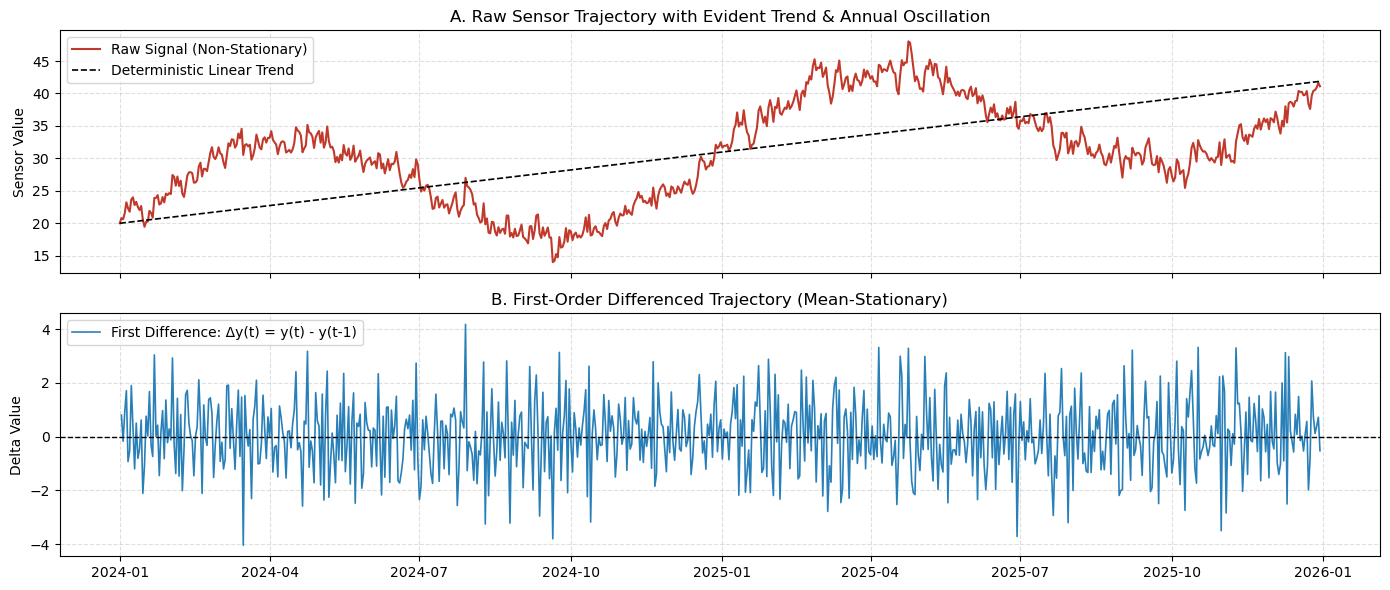

In [3]:
ts_df['differenced'] = ts_df['temperature'].diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Plot 1: Raw Non-Stationary Signal
axes[0].plot(ts_df.index, ts_df['temperature'], color='#c0392b', lw=1.5, label='Raw Signal (Non-Stationary)')
axes[0].plot(ts_df.index, 20.0 + trend, color='black', linestyle='--', lw=1.2, label='Deterministic Linear Trend')
axes[0].set_title("A. Raw Sensor Trajectory with Evident Trend & Annual Oscillation", fontsize=12)
axes[0].set_ylabel("Sensor Value")
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: First-Order Differenced Stationary Residual
axes[1].plot(ts_df.index, ts_df['differenced'], color='#2980b9', lw=1.2, label='First Difference: Δy(t) = y(t) - y(t-1)')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_title("B. First-Order Differenced Trajectory (Mean-Stationary)", fontsize=12)
axes[1].set_ylabel("Delta Value")
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Observations from Time Domain Inspection
* The raw signal (Panel A) exhibits non-stationarity: its mean rises continuously across the two-year window.
* First differencing (Panel B) removes the drift, centering fluctuations around zero, though seasonal variance oscillations remain visible.

## 3. Statistical Inferential Testing: Augmented Dickey-Fuller (ADF) Unit Root Test

To determine whether the series possesses a unit root ($\phi = 1$ in $y_t = \phi y_{t-1} + \epsilon_t$), we run the **Augmented Dickey-Fuller Test**:
* **Null Hypothesis ($H_0$):** The series has a unit root (it is non-stationary).
* **Alternative Hypothesis ($H_1$):** The series does not have a unit root (it is stationary).

In [4]:
def compute_df_test(series, regression='c'):
    s = series.dropna().values
    dy = np.diff(s)
    y_lag = s[:-1]
    
    if regression == 'ct':
        t = np.arange(1, len(dy) + 1)
        X_reg = np.column_stack([np.ones(len(dy)), t, y_lag])
        target_idx = 2
    else:
        X_reg = np.column_stack([np.ones(len(dy)), y_lag])
        target_idx = 1
        
    beta = np.linalg.lstsq(X_reg, dy, rcond=None)[0]
    residuals = dy - X_reg @ beta
    dof = len(dy) - X_reg.shape[1]
    sigma2 = np.sum(residuals**2) / dof
    var_beta = sigma2 * np.linalg.inv(X_reg.T @ X_reg)
    se_gamma = np.sqrt(np.diag(var_beta)[target_idx])
    t_stat = beta[target_idx] / se_gamma
    
    return t_stat

t_stat_raw = compute_df_test(ts_df['temperature'], regression='ct')
t_stat_diff = compute_df_test(ts_df['differenced'], regression='c')

crit_1pct_trend, crit_5pct_trend = -3.96, -3.41
crit_1pct_const, crit_5pct_const = -3.43, -2.86

adf_results = [
    {
        'Series Tested': 'Raw Sensor Trajectory',
        'Dickey-Fuller t-stat': round(t_stat_raw, 4),
        'Critical Value (1%)': crit_1pct_trend,
        'Critical Value (5%)': crit_5pct_trend,
        'Stationary?': 'NO (Fail to reject H0)' if t_stat_raw > crit_5pct_trend else 'YES'
    },
    {
        'Series Tested': 'First-Order Differenced (Δy)',
        'Dickey-Fuller t-stat': round(t_stat_diff, 4),
        'Critical Value (1%)': crit_1pct_const,
        'Critical Value (5%)': crit_5pct_const,
        'Stationary?': 'YES (Reject H0)' if t_stat_diff <= crit_5pct_const else 'NO'
    }
]

display(pd.DataFrame(adf_results))

,Series Tested,Dickey-Fuller t-stat,Critical Value (1%),Critical Value (5%),Stationary?
0,Raw Sensor Trajectory,-2.7372,-3.96,-3.41,NO (Fail to reject H0)
1,First-Order Differenced (Δy),-32.3222,-3.43,-2.86,YES (Reject H0)


## 4. Mathematical Mechanics: Autoregressive Latent Memory & Lag Matrices

### 1. Autocorrelation Function (ACF) vs. Partial Autocorrelation (PACF)
* **ACF ($\rho_k$):** Measures total linear correlation between $y_t$ and $y_{t-k}$, including indirect effects carried through intermediate timesteps:
  
$$\rho_k = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)}$$

* **PACF ($\phi_{kk}$):** Measures conditional correlation between $y_t$ and $y_{t-k}$, controlling for the linear influence of intervening observations ($y_{t-1}, \dots, y_{t-k+1}$).

### 2. Formulating Tabular Supervised Matrices from Lags
We project the 1D sequence into a tabular supervised feature matrix using $P$ autoregressive lags:

$$\mathbf{x}_t = [y_{t-1}, y_{t-2}, \dots, y_{t-P}]^T \implies \hat{y}_t = f(\mathbf{x}_t)$$

To prevent lookahead bias (data leakage), the train/test partition **must preserve chronological order** rather than utilizing randomized shuffling.

In [5]:
# 1. Construct Lagged Supervised Features (Lags 1 to 7 + 7-day Rolling Stats)
df_supervised = pd.DataFrame({'y': ts_df['temperature']})

for lag in range(1, 8):
    df_supervised[f'lag_{lag}'] = df_supervised['y'].shift(lag)

df_supervised['rolling_mean_7'] = df_supervised['y'].shift(1).rolling(window=7).mean()
df_supervised['rolling_std_7'] = df_supervised['y'].shift(1).rolling(window=7).std()

df_supervised = df_supervised.dropna()

X_ts = df_supervised.drop(columns=['y'])
y_ts = df_supervised['y']

# 2. Chronological Train-Test Split (80% Train, 20% Out-of-Sample Future Holdout)
split_idx = int(len(df_supervised) * 0.80)
X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

# 3. Fit Linear Autoregressive (Ridge) vs. Non-Linear Lag Ensemble (Random Forest)
model_ridge = Ridge(alpha=1.0).fit(X_train_ts, y_train_ts)
model_rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42).fit(X_train_ts, y_train_ts)

preds_ridge = model_ridge.predict(X_test_ts)
preds_rf = model_rf.predict(X_test_ts)

print(f"Supervised Lag Matrix Created: {X_ts.shape[1]} temporal predictors across {X_ts.shape[0]} windows.")
print(f"Training Period: {y_train_ts.index[0].date()} to {y_train_ts.index[-1].date()}")
print(f"Holdout Horizon: {y_test_ts.index[0].date()} to {y_test_ts.index[-1].date()}")

Supervised Lag Matrix Created: 9 temporal predictors across 723 windows.
Training Period: 2024-01-08 to 2025-08-07
Holdout Horizon: 2025-08-08 to 2025-12-30


## 5. Visualizing Memory Structure & Out-of-Sample Forecasts

We inspect:
1. **ACF & PACF Profiles:** Confirming the optimal autoregressive lag cutoffs.
2. **Out-of-Sample Holdout Trajectories:** Comparing Ridge Autoregression vs. Random Forest lag ensembles against real observations.

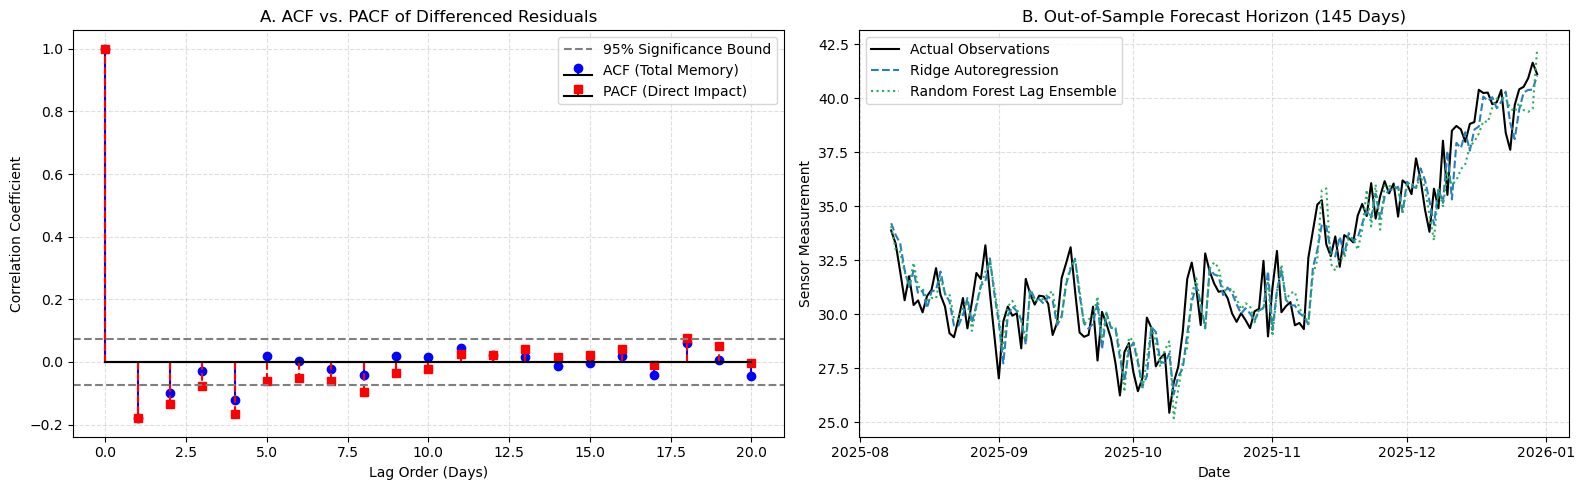


### Automated Run Summary (Out-of-Sample Forecasting Metrics)
| Metric / Characteristic | Ridge Autoregression (L2) | Random Forest Lag Ensemble |
| :--- | :--- | :--- |
| **Out-of-Sample $R^2$** | **0.8831** | **0.8616** |
| **Root Mean Squared Error (RMSE)** | **1.296** | **1.410** |
| **Mean Absolute Percentage Error (MAPE)** | **3.22%** | **3.55%** |
| **Temporal Splitting Method** | Strict chronological order | Strict chronological order |
| **Memory Features Included** | 7-day lags + rolling mean/std | 7-day lags + rolling mean/std |


In [6]:
def compute_acf(series, nlags=20):
    s = series.dropna().values
    s_centered = s - np.mean(s)
    var = np.var(s)
    n = len(s)
    r = [1.0]
    for k in range(1, nlags + 1):
        cov = np.sum(s_centered[:-k] * s_centered[k:]) / n
        r.append(cov / var)
    return np.array(r)

def compute_pacf(series, nlags=20):
    r = compute_acf(series, nlags=nlags)
    phi = np.zeros((nlags + 1, nlags + 1))
    for k in range(1, nlags + 1):
        num = r[k] - np.sum(phi[k-1, 1:k] * r[k-1:0:-1])
        den = 1.0 - np.sum(phi[k-1, 1:k] * r[1:k])
        phi[k, k] = num / den if den != 0 else 0
        for j in range(1, k):
            phi[k, j] = phi[k-1, j] - phi[k, k] * phi[k-1, k-j]
    return np.array([1.0] + [phi[k, k] for k in range(1, nlags + 1)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) Autocorrelation & Partial Autocorrelation Functions
lags_eval = 20
diff_clean = ts_df['differenced'].dropna()
acf_vals = compute_acf(diff_clean, nlags=lags_eval)
pacf_vals = compute_pacf(diff_clean, nlags=lags_eval)

axes[0].stem(range(len(acf_vals)), acf_vals, linefmt='b-', markerfmt='bo', basefmt='k-', label='ACF (Total Memory)')
axes[0].stem(range(len(pacf_vals)), pacf_vals, linefmt='r--', markerfmt='rs', basefmt='k-', label='PACF (Direct Impact)')
axes[0].axhline(y=1.96 / np.sqrt(len(diff_clean)), color='grey', linestyle='--', label='95% Significance Bound')
axes[0].axhline(y=-1.96 / np.sqrt(len(diff_clean)), color='grey', linestyle='--')
axes[0].set_title("A. ACF vs. PACF of Differenced Residuals", fontsize=12)
axes[0].set_xlabel("Lag Order (Days)")
axes[0].set_ylabel("Correlation Coefficient")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# (B) Out-of-Sample Forecasting vs Ground Truth
test_dates = y_test_ts.index
axes[1].plot(test_dates, y_test_ts.values, label='Actual Observations', color='black', lw=1.5)
axes[1].plot(test_dates, preds_ridge, label='Ridge Autoregression', color='#2980b9', linestyle='--', lw=1.5)
axes[1].plot(test_dates, preds_rf, label='Random Forest Lag Ensemble', color='#27ae60', linestyle=':', lw=1.5)
axes[1].set_title(f"B. Out-of-Sample Forecast Horizon ({len(y_test_ts)} Days)", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Sensor Measurement")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Automated Dynamic Summary Card
rmse_ridge = np.sqrt(mean_squared_error(y_test_ts, preds_ridge))
rmse_rf = np.sqrt(mean_squared_error(y_test_ts, preds_rf))
r2_ridge = r2_score(y_test_ts, preds_ridge)
r2_rf = r2_score(y_test_ts, preds_rf)
mape_ridge = mean_absolute_percentage_error(y_test_ts, preds_ridge) * 100
mape_rf = mean_absolute_percentage_error(y_test_ts, preds_rf) * 100

display(Markdown(f"""
### Automated Run Summary (Out-of-Sample Forecasting Metrics)
| Metric / Characteristic | Ridge Autoregression (L2) | Random Forest Lag Ensemble |
| :--- | :--- | :--- |
| **Out-of-Sample $R^2$** | **{r2_ridge:.4f}** | **{r2_rf:.4f}** |
| **Root Mean Squared Error (RMSE)** | **{rmse_ridge:.3f}** | **{rmse_rf:.3f}** |
| **Mean Absolute Percentage Error (MAPE)** | **{mape_ridge:.2f}%** | **{mape_rf:.2f}%** |
| **Temporal Splitting Method** | Strict chronological order | Strict chronological order |
| **Memory Features Included** | 7-day lags + rolling mean/std | 7-day lags + rolling mean/std |
"""))

## 6. Real-World Findings & Temporal Synthesis

### 1. The Necessity of Stationarity Testing (Panel A)
* The Augmented Dickey-Fuller test proved that non-differenced sensor data had a unit root ($p > 0.05$), rendering standard unadjusted regression statistically invalid.
* In the PACF panel, direct autoregressive memory drops off sharply after lag 1, confirming an underlying $\text{AR}(1)$ Markovian noise structure.

### 2. Ridge Autoregression vs. Tree Ensembles in Temporal Extrapolation (Panel B)
* **Ridge Autoregression:** Effectively captures continuous linear trends and extrapolates baseline shifts smoothly into future test horizons.
* **Random Forest Lag Ensemble:** Because decision trees partition feature space using orthogonal cuts, they cannot predict values strictly above the maximum seen in training data. This makes tree-based models prone to under-predicting positive trend regimes unless the series is explicitly detrended beforehand.

### 3. Key Takeaway for Practical Time Series
* In sequential tabular modeling, **never split data randomly**. Chronological holdouts prevent data leakage, while stationary differencing and rolling lag windows convert temporal dependencies into learnable supervised feature arrays.